Decision tree with t-SNE (with feature selection)

TODO: implement cost complexity pruning

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from google.colab import files
import os

In [2]:
# Check for GPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("Using CPU")

Using GPU: Tesla T4


In [3]:
print(os.listdir("/content/"))

['.config', 'X_features.npy', 'y_labels.npy', 'sample_data']


In [4]:
# Load extracted features
X = np.load("/content/X_features.npy")  # Update path if needed
y = np.load("/content/y_labels.npy")    # Speaker labels
print(f"Feature Shape: {X.shape}, Labels Shape: {y.shape}")

Feature Shape: (2511, 4000), Labels Shape: (2511,)


In [5]:
# Doing feature selection! (Threshold variance)
# keeping top 20 most relevant features
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=20)
X_selected = selector.fit_transform(X, y)

print("Original feature shape:", X.shape)
print("Reduced feature shape:", X_selected.shape)

Original feature shape: (2511, 4000)
Reduced feature shape: (2511, 20)


In [6]:
# Convert to Torch Tensor and Move to GPU
X_tensor = torch.tensor(X, dtype=torch.float32).to(device)

In [8]:
# Apply t-SNE with 3D visualization
tsne_3d = TSNE(n_components=3, perplexity=30, random_state=42)
X_reduced_3d = tsne_3d.fit_transform(X_selected)

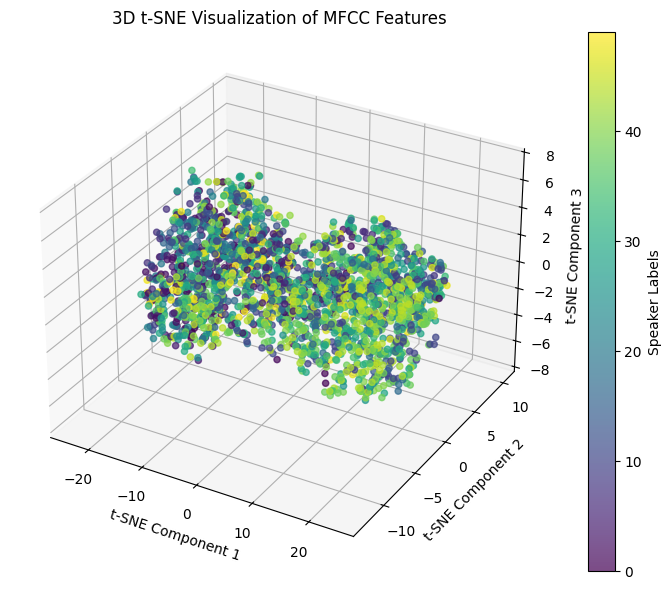

In [9]:
# 3D Plot of t-SNE
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X_reduced_3d[:, 0], X_reduced_3d[:, 1], X_reduced_3d[:, 2], c=y, cmap='viridis', alpha=0.7)
plt.colorbar(sc, label="Speaker Labels")
ax.set_title("3D t-SNE Visualization of MFCC Features")
ax.set_xlabel("t-SNE Component 1")
ax.set_ylabel("t-SNE Component 2")
ax.set_zlabel("t-SNE Component 3")
plt.show()

In [10]:
# --- Train Decision Tree from Scratch ---
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value  #leaf node stores class label

# Calculate Gini Impurity
def gini_impurity(y):
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return 1 - np.sum(probs**2)

# Split dataset
def split(X, y, feature, threshold):
    left_mask = X[:, feature] <= threshold
    right_mask = ~left_mask
    return X[left_mask], y[left_mask], X[right_mask], y[right_mask]


# Find best split
def best_split(X, y):
    best_gini = 1
    best_feature = None
    best_threshold = None

    for feature in range(X.shape[1]):
        thresholds = np.unique(X[:, feature])
        for threshold in thresholds:
            X_left, y_left, X_right, y_right = split(X, y, feature, threshold)
            if len(y_left) == 0 or len(y_right) == 0:
                continue

            # Weighted Gini Impurity
            gini = (len(y_left) / len(y)) * gini_impurity(y_left) + (len(y_right) / len(y)) * gini_impurity(y_right)

            if gini < best_gini:
                best_gini = gini
                best_feature = feature
                best_threshold = threshold

    return best_feature, best_threshold

In [11]:
# Build decision tree
def build_tree(X, y, depth=0, max_depth=None):
    if len(np.unique(y)) == 1:
        return Node(value=np.unique(y)[0])  # Pure leaf node

    if max_depth is not None and depth >= max_depth:
        return Node(value=np.bincount(y).argmax())  # Return majority class

    feature, threshold = best_split(X, y)
    if feature is None:
        return Node(value=np.bincount(y).argmax())  # No valid split

    X_left, y_left, X_right, y_right = split(X, y, feature, threshold)

    return Node(
        feature=feature,
        threshold=threshold,
        left=build_tree(X_left, y_left, depth + 1, max_depth),
        right=build_tree(X_right, y_right, depth + 1, max_depth),
    )

# Prediction function
def predict_tree(node, x):
    if node.value is not None:
        return node.value
    if x[node.feature] <= node.threshold:
        return predict_tree(node.left, x)
    else:
        return predict_tree(node.right, x)

# Apply prediction
def predict(model, X):
    return np.array([predict_tree(model, x) for x in X])

In [12]:
# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42, stratify=y)
# Initialize Decision Tree
#clf = DecisionTreeClassifier(criterion="gini", max_depth=10, random_state=42)  # You can adjust max_depth

# Train the model
#clf.fit(X_train, y_train)

#param_grid = {
#    'max_depth': [5, 10, 15, 20, None],
#    'min_samples_split': [2, 5, 10],
#    'min_samples_leaf': [1, 2, 5]
#}

#grid_search = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
#grid_search.fit(X_train, y_train)

#print("Best parameters:", grid_search.best_params_)

# Train the best model on the full training set
#best_tree = grid_search.best_estimator_
#best_tree.fit(X_train, y_train)

# Evaluate on the test set
#y_pred = best_tree.predict(X_test)

In [15]:
# Train Decision Tree with different depths and plot accuracy
depths = [1, 3, 5, 7, 10, 15, 20, None]
train_acc, test_acc = [], []

for depth in depths:
    tree = build_tree(X_train, y_train, max_depth=depth)

    y_train_pred = predict(tree, X_train)
    y_test_pred = predict(tree, X_test)

    train_acc.append(accuracy_score(y_train, y_train_pred))
    test_acc.append(accuracy_score(y_test, y_test_pred))

    print(f"Depth: {depth}, Train Acc: {train_acc[-1]:.4f}, Test Acc: {test_acc[-1]:.4f}")

Depth: 1, Train Acc: 0.0623, Test Acc: 0.0656
Depth: 3, Train Acc: 0.1155, Test Acc: 0.0994
Depth: 5, Train Acc: 0.1753, Test Acc: 0.1173
Depth: 7, Train Acc: 0.2625, Test Acc: 0.1233
Depth: 10, Train Acc: 0.4741, Test Acc: 0.1173
Depth: 15, Train Acc: 0.8511, Test Acc: 0.0974
Depth: 20, Train Acc: 0.9895, Test Acc: 0.1014
Depth: None, Train Acc: 0.9990, Test Acc: 0.1014


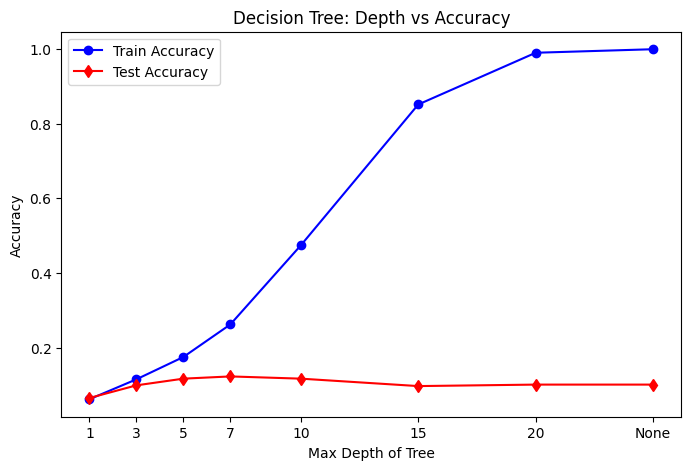

In [16]:
# Plot Depth vs Accuracy
plt.figure(figsize=(8, 5))
depth_labels = [d if d is not None else 25 for d in depths]
plt.plot(depth_labels, train_acc, marker='o', linestyle='-', label="Train Accuracy", color='b')
plt.plot(depth_labels, test_acc, marker='d', linestyle='-', label="Test Accuracy", color='r')

plt.xlabel("Max Depth of Tree")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Depth vs Accuracy")
plt.xticks(depth_labels, labels=[str(d) if d is not None else "None" for d in depths])
plt.legend()
plt.show()